In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2, l1_l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.datasets import mnist
from tensorflow.keras import regularizers

In [16]:
# Step 1: Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()  # Load the dataset

# Normalize the pixel values to the range [0, 1]
x_train = x_train.astype('float32') / 255.0  # Scale training data
x_test = x_test.astype('float32') / 255.0  # Scale test data

# One-hot encode the labels (0-9) for categorical classification
y_train = to_categorical(y_train, 10)  # Encode training labels
y_test = to_categorical(y_test, 10)  # Encode test labels

# ***Using a lower learning rate & batch noralization and dropout layer***

In [17]:
model_v4 = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='selu'),    #-----------------------------> uinsg Selu in the 4th layer
    Dropout(0.2),
    Dense(10, activation='softmax')
])
model_v4.summary()

model_v4.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

history = model_v4.fit(x_train, y_train, epochs=15, batch_size=32, validation_split=0.2)

test_loss, test_accuracy = model_v4.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")



/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,298 (954.29 KB)

 Trainable params: 243,530 (951.29 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7200 - loss: 0.9161 - val_accuracy: 0.9236 - val_loss: 0.2509
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8721 - loss: 0.4194 - val_accuracy: 0.9462 - val_loss: 0.1798
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9013 - loss: 0.3253 - val_accuracy: 0.9548 - val_loss: 0.1504
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9182 - loss: 0.2667 - val_accuracy: 0.9617 - val_loss: 0.1298
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9291 - loss: 0.2343 - val_accuracy: 0.9657 - val_loss: 0.1191
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9377 - loss: 0.2056 - val_accuracy: 0.9681 - val_loss: 0.1086
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9430 - loss: 0.1889 - val_accuracy: 0.9707 - val_loss: 0.1015
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9482 - loss: 0.

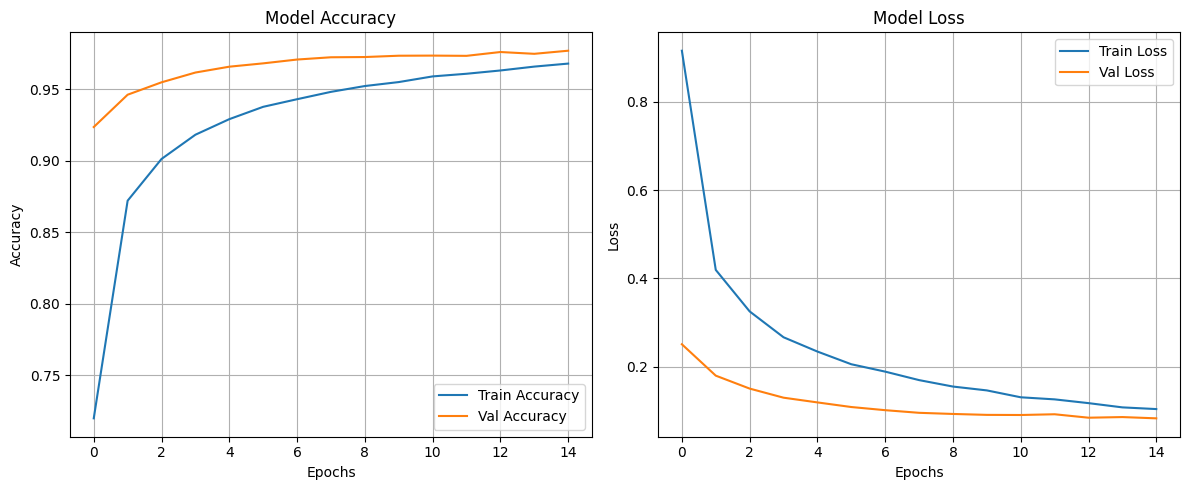

In [18]:


# Step 6: Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 5))  # Create a figure with a specific size

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)  # Create a subplot for accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')  # Plot training accuracy
plt.plot(history.history['val_accuracy'], label='Val Accuracy')  # Plot validation accuracy
plt.title('Model Accuracy')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Accuracy')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

# Plot training & validation loss values
plt.subplot(1, 2, 2)  # Create a subplot for loss
plt.plot(history.history['loss'], label='Train Loss')  # Plot training loss
plt.plot(history.history['val_loss'], label='Val Loss')  # Plot validation loss
plt.title('Model Loss')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Loss')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

plt.tight_layout()  # Adjust subplots to fit into figure area
plt.show()  # Display the plots

# ***Using  L1 & L2 Resulaerization for this model***

In [19]:
model_v5 = Sequential([
    Flatten(input_shape=(28, 28)),

    # Dense layer with L1 regularization
    Dense(256, activation='relu', kernel_regularizer=regularizers.l1(0.01)),

    # Dense layer with L2 regularization
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),

    # Dense layer with L2 regularization
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),

    Dense(10, activation='softmax')
])

model_v5.summary()

model_v5.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

history = model_v5.fit(x_train, y_train, epochs=15, batch_size=32, validation_split=0.2)

test_loss, test_accuracy = model_v5.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")



Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7215 - loss: 16.2134 - val_accuracy: 0.8077 - val_loss: 2.0289
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8201 - loss: 1.7254 - val_accuracy: 0.8420 - val_loss: 1.4935
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8395 - loss: 1.4268 - val_accuracy: 0.8554 - val_loss: 1.3238
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8474 - loss: 1.2977 - val_accuracy: 0.8587 - val_loss: 1.2274
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8523 - loss: 1.2206 - val_accuracy: 0.8633 - val_loss: 1.1590
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8574 - loss: 1.1652 - val_accuracy: 0.8667 - val_loss: 1.1119
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8589 - loss: 1.1257 - val_accuracy: 0.8710 - val_loss: 1.0759
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8618 - loss: 1

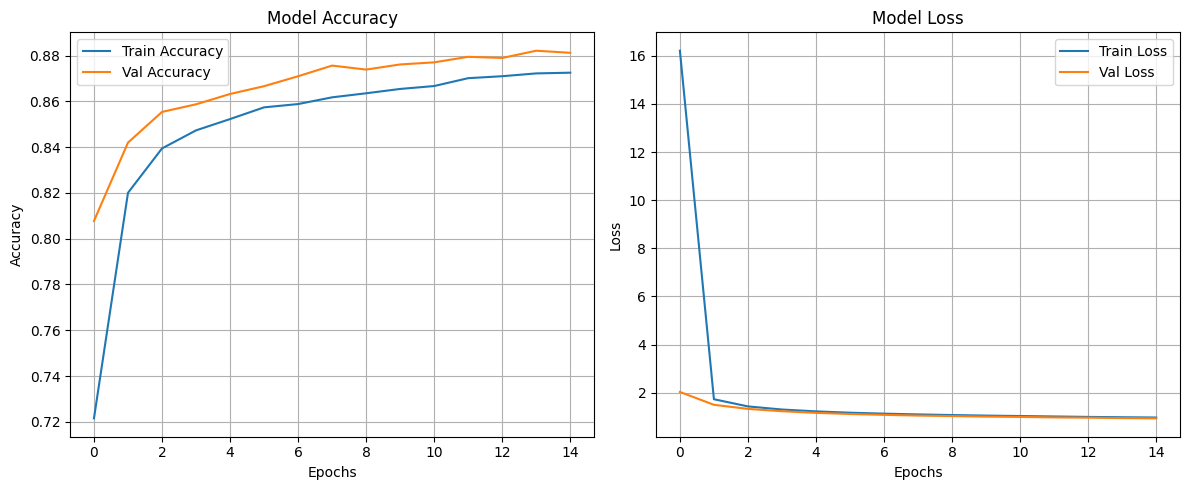

In [20]:


# Step 6: Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 5))  # Create a figure with a specific size

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)  # Create a subplot for accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')  # Plot training accuracy
plt.plot(history.history['val_accuracy'], label='Val Accuracy')  # Plot validation accuracy
plt.title('Model Accuracy')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Accuracy')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

# Plot training & validation loss values
plt.subplot(1, 2, 2)  # Create a subplot for loss
plt.plot(history.history['loss'], label='Train Loss')  # Plot training loss
plt.plot(history.history['val_loss'], label='Val Loss')  # Plot validation loss
plt.title('Model Loss')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Loss')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

plt.tight_layout()  # Adjust subplots to fit into figure area
plt.show()  # Display the plots

# ***Combining the both soloution to check the results***

In [21]:
model_combine = Sequential([
    Flatten(input_shape=(28, 28)),

    Dense(256, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='selu'),    #-----------------------------> using Selu in the 4th layer
    Dropout(0.2),

    Dense(10, activation='softmax')
])

model_combine.summary()

model_combine.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

history = model_combine.fit(x_train, y_train, epochs=30,batch_size=32, validation_split=0.2, callbacks=[EarlyStopping( monitor='val_loss',patience=5,restore_best_weights=True)]
)

test_loss_combine, test_accuracy_combine = model_combine.evaluate(x_test, y_test)
print(f"Model Combine Test Accuracy: {test_accuracy_combine:.4f}")


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,298 (954.29 KB)

 Trainable params: 243,530 (951.29 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7284 - loss: 1.0042 - val_accuracy: 0.9228 - val_loss: 0.3739
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8741 - loss: 0.5376 - val_accuracy: 0.9459 - val_loss: 0.3012
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9035 - loss: 0.4395 - val_accuracy: 0.9555 - val_loss: 0.2662
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9193 - loss: 0.3840 - val_accuracy: 0.9606 - val_loss: 0.2457
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9306 - loss: 0.3403 - val_accuracy: 0.9650 - val_loss: 0.2273
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9388 - loss: 0.3124 - val_accuracy: 0.9672 - val_loss: 0.2153
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9460 - loss: 0.2887 - val_accuracy: 0.9686 - val_loss: 0.2090
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9512 - loss: 0

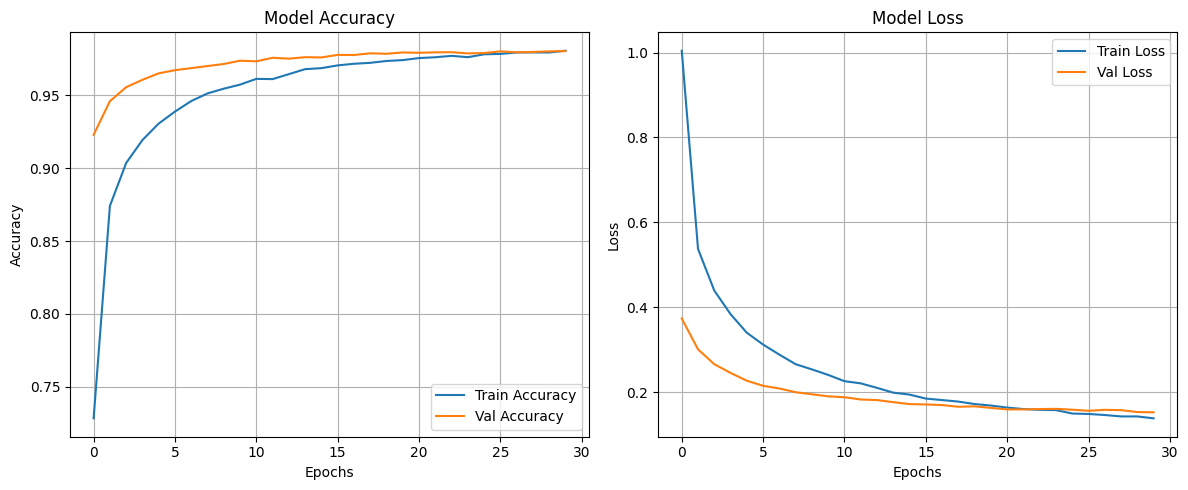

In [22]:
# Step 6: Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 5))  # Create a figure with a specific size

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)  # Create a subplot for accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')  # Plot training accuracy
plt.plot(history.history['val_accuracy'], label='Val Accuracy')  # Plot validation accuracy
plt.title('Model Accuracy')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Accuracy')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

# Plot training & validation loss values
plt.subplot(1, 2, 2)  # Create a subplot for loss
plt.plot(history.history['loss'], label='Train Loss')  # Plot training loss
plt.plot(history.history['val_loss'], label='Val Loss')  # Plot validation loss
plt.title('Model Loss')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Loss')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

plt.tight_layout()  # Adjust subplots to fit into figure area
plt.show()  # Display the plots

The main problem being addressed is overfitting, where a model learns the training data too closely instead of learning patterns that generalize to new data.

1. L1/L2 Regularization – controlling weights
Regularization adds a penalty for large weights. L1 can make some weights zero, while L2 keeps weights small. This helps prevent the model from becoming too complex and reduces overfitting.

2. Dropout – randomly removing neurons
Dropout randomly turns off some neurons during training. This prevents neurons from relying too much on each other and forces the network to learn more general features.

3. Batch Normalization – stabilizing training
Batch Normalization keeps the values passed between layers more stable. This can make training faster and more reliable, while also providing a small amount of regularization.

***we see that using all of them also using the previous model artecture that game us better results gave us a much better and fine tuned results***
